## Regresion Salarial

Carpeta actual: c:\Users\rocio\OneDrive\Desktop\ProyectoFinal\Evaluador-de-Sesgo-y-Fuga-de-Talento-STEM\notebooks

Shape del dataset: (100, 10)


,id,salario_anual,moneda,genero,anios_experiencia,cargo,sector,pais,ciudad,tipo_jornada
0,1,24000,eur,mujer,0,junior developer,software,españa,madrid,tiempo completo
1,2,27000,eur,hombre,0,junior developer,software,españa,madrid,tiempo completo
2,3,26000,eur,mujer,1,junior developer,fintech,españa,barcelona,tiempo completo
3,4,29000,eur,hombre,1,junior developer,fintech,españa,barcelona,tiempo completo
4,5,25000,eur,no binario,1,data analyst,consultoría,españa,madrid,tiempo completo



Columnas:
['id', 'salario_anual', 'moneda', 'genero', 'anios_experiencia', 'cargo', 'sector', 'pais', 'ciudad', 'tipo_jornada']

Tipos de datos:
id                   int64
salario_anual        int64
moneda                 str
genero                 str
anios_experiencia    int64
cargo                  str
sector                 str
pais                   str
ciudad                 str
tipo_jornada           str
dtype: object

Valores nulos:
id                   0
salario_anual        0
moneda               0
genero               0
anios_experiencia    0
cargo                0
sector               0
pais                 0
ciudad               0
tipo_jornada         0
dtype: int64

Tamaño train: (80, 7)
Tamaño test: (20, 7)

Resultados del modelo de regresión:
MAE: 1142.17
RMSE: 1593.95
R2: 0.9741


,salario_real,salario_predicho
0,57000,56628.150223
1,32000,34874.977123
2,46000,46660.745187
3,55000,55270.481262
4,51000,53095.093197
5,50000,49736.060298
6,46000,45550.991408
7,50000,49970.891732
8,36000,34055.660991
9,24000,24317.492698


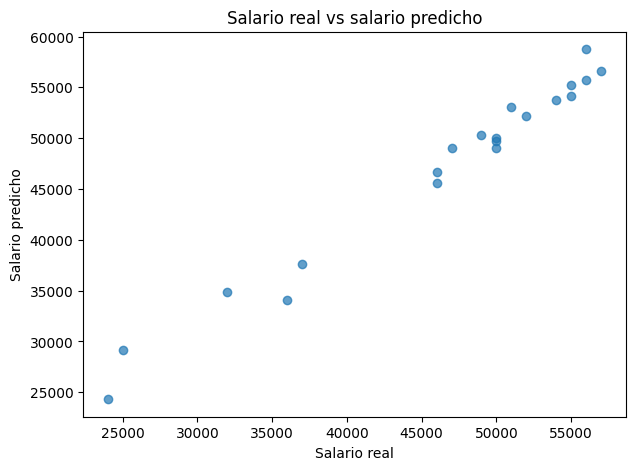


Salario medio por género:


,genero,salario_anual
0,hombre,51150.0
3,prefiere no decir,44900.0
1,mujer,44600.0
2,no binario,42000.0


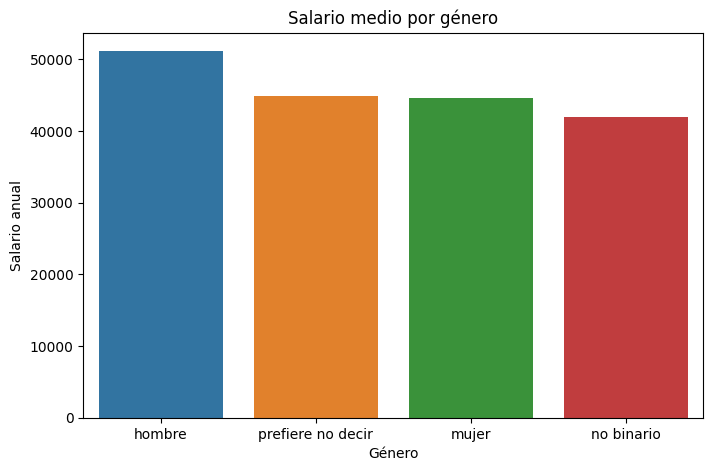


Brecha salarial media (hombre - mujer): 6550.0

Ejemplo de predicción:


,genero,anios_experiencia,cargo,sector,pais,ciudad,tipo_jornada
0,mujer,5,data scientist,fintech,españa,madrid,tiempo completo


Salario predicho: 37660.33


In [1]:
# ==========================================
# NOTEBOOK: 02_regresion_salarial.ipynb
# OBJETIVO:
# Predecir salario anual y analizar brecha salarial
# ==========================================

# ==========
# 1. LIBRERÍAS
# ==========
import os
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

# ==========
# 2. DETECTAR RUTA BASE
# ==========
print("Carpeta actual:", os.getcwd())

if Path("data/processed").exists():
    BASE_PATH = Path(".")
elif Path("../data/processed").exists():
    BASE_PATH = Path("..")
else:
    raise FileNotFoundError("No se encontró la carpeta data/processed")

PROCESSED_PATH = BASE_PATH / "data" / "processed"

# ==========
# 3. CARGAR DATASET LIMPIO
# ==========
file_path = PROCESSED_PATH / "salarios_stem_clean.csv"
df = pd.read_csv(file_path)

print("\nShape del dataset:", df.shape)
display(df.head())

# ==========
# 4. REVISIÓN BÁSICA
# ==========
print("\nColumnas:")
print(df.columns.tolist())

print("\nTipos de datos:")
print(df.dtypes)

print("\nValores nulos:")
print(df.isnull().sum())

# ==========
# 5. VARIABLES DEL MODELO
# Objetivo: salario_anual
# ==========
target = "salario_anual"

features = [
    "genero",
    "anios_experiencia",
    "cargo",
    "sector",
    "pais",
    "ciudad",
    "tipo_jornada"
]

X = df[features].copy()
y = df[target].copy()

# ==========
# 6. DEFINIR COLUMNAS NUMÉRICAS Y CATEGÓRICAS
# ==========
categorical_features = [
    "genero",
    "cargo",
    "sector",
    "pais",
    "ciudad",
    "tipo_jornada"
]

numeric_features = [
    "anios_experiencia"
]

# ==========
# 7. PREPROCESADO
# OneHotEncoder convierte texto a variables numéricas
# ==========
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

# ==========
# 8. MODELO
# ==========
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# ==========
# 9. DIVIDIR TRAIN / TEST
# ==========
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("\nTamaño train:", X_train.shape)
print("Tamaño test:", X_test.shape)

# ==========
# 10. ENTRENAR
# ==========
model.fit(X_train, y_train)

# ==========
# 11. PREDECIR
# ==========
y_pred = model.predict(X_test)

# ==========
# 12. MÉTRICAS
# ==========
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nResultados del modelo de regresión:")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2:", round(r2, 4))

# ==========
# 13. COMPARAR VALORES REALES VS PREDICHOS
# ==========
results = pd.DataFrame({
    "salario_real": y_test.values,
    "salario_predicho": y_pred
})

display(results.head(10))

# ==========
# 14. GRÁFICO REAL VS PREDICHO
# ==========
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Salario real")
plt.ylabel("Salario predicho")
plt.title("Salario real vs salario predicho")
plt.show()

# ==========
# 15. ANÁLISIS SIMPLE DE BRECHA SALARIAL
# Comparar salario medio por género
# ==========
salary_by_gender = df.groupby("genero")["salario_anual"].mean().reset_index()
salary_by_gender = salary_by_gender.sort_values(by="salario_anual", ascending=False)

print("\nSalario medio por género:")
display(salary_by_gender)

plt.figure(figsize=(8, 5))
sns.barplot(data=salary_by_gender, x="genero", y="salario_anual", hue="genero", dodge=False, legend=False)
plt.title("Salario medio por género")
plt.xlabel("Género")
plt.ylabel("Salario anual")
plt.show()

# ==========
# 16. BRECHA MUJER VS HOMBRE
# ==========
avg_mujer = df[df["genero"] == "mujer"]["salario_anual"].mean()
avg_hombre = df[df["genero"] == "hombre"]["salario_anual"].mean()

if pd.notna(avg_mujer) and pd.notna(avg_hombre):
    gap = avg_hombre - avg_mujer
    print("\nBrecha salarial media (hombre - mujer):", round(gap, 2))
else:
    print("\nNo se pudo calcular la brecha salarial entre hombre y mujer.")

# ==========
# 17. EJEMPLO DE PREDICCIÓN
# ==========
sample = pd.DataFrame([{
    "genero": "mujer",
    "anios_experiencia": 5,
    "cargo": "data scientist",
    "sector": "fintech",
    "pais": "españa",
    "ciudad": "madrid",
    "tipo_jornada": "tiempo completo"
}])

pred_salary = model.predict(sample)[0]

print("\nEjemplo de predicción:")
display(sample)
print("Salario predicho:", round(pred_salary, 2))
